# Variational Autoencoder for cat images

## Imports

In [7]:
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

from scripts import (
    DataFixedConfig,
    DataGridConfig,
    TrainFixedConfig,
    TrainGridConfig,
    VAEExperiment,
    VAEFixedConfig,
    VAEGridConfig,
    build_dataloaders,
    build_vae,
    compute_fid,
    count_parameters,
    expand_experiment_grid,
    interpolate_vae,
    output_paths,
    prepare_data,
    report_fid,
    run_name,
    sample_vae_latents,
    save_history,
    save_history_plot,
    save_interpolation_grid,
    save_json,
    save_sample_grid,
    train_vae,
    update_total_stats,
    vae_sample_iterator,
)

## Parameters

In [8]:
# Training time on a free Colab T4 GPU at image_size=64 and ~14k cats:
#   batch_size=64, latent_dim=128, base_channels=32 -> ~30s per epoch.
#   30 epochs ~= 15 minutes total. Each beta sweep multiplies that by len(beta).

EXPERIMENT_NAME = "vae"

# --- Data ---------------------------------------------------------------
DATA_DIR = "../data/cats-faces"
OUTPUT_DIR = "../reports/runs"
CACHE_DIR = "../.cache/fid"
IMAGE_SIZE = 64
TRAIN_FRACTION = 0.9
VALIDATION_FRACTION = 0.1
AUGMENT_FLIP = False    # horizontal flip ~doubles effective training data
GRAYSCALE = False      # True collapses RGB to 1 channel (channels auto-set below)
POSTERIZE_BITS = 6  # None disables; e.g. 4 keeps 16 levels/channel, 2 keeps 4

# --- Model --------------------------------------------------------------
LATENT_DIM = 128       # 256 gives richer latent space for complex cat images
HIDDEN_DIM = 512
BASE_CHANNELS = 96     # ~4x conv params over 32; sharper detail at higher compute cost
BETA = 0.8             # < 1 prioritizes reconstruction fidelity over latent regularity
KL_ANNEAL_EPOCHS = 20  # 0 disables; linearly ramp 0 -> BETA over the first N epochs.
                       # Computed from absolute epoch, so resumes pick up at the right value.
AMP = True             # mixed-precision (fp16) training on CUDA; ~1.5-2x faster, half memory.

# --- Optimization -------------------------------------------------------
LEARNING_RATE = 5e-4   # Adam sweet spot; 1e-3 can overshoot on image VAEs
WEIGHT_DECAY = 1e-6    # mild L2 regularization
EPOCHS = 100           # upper bound; early stopping usually trips well before
BATCH_SIZE = 64
SEED = 42

# --- Early stopping -----------------------------------------------------
# Aggressive: stop unless validation_loss improves by at least MIN_DELTA
# within PATIENCE epochs. Sub-MIN_DELTA wiggles are treated as noise.
EARLY_STOPPING = True
EARLY_STOPPING_PATIENCE = 20
EARLY_STOPPING_MIN_DELTA = 0.5
EARLY_STOPPING_RESTORE_BEST = True

# --- Checkpointing ------------------------------------------------------
# Final checkpoint lands in the run's own checkpoints/ folder by default.
SAVE_CHECKPOINT = True  # Save model + optimizer + history at end of training
# NOTE: BN->GN architecture change invalidates pre-change checkpoints (state_dict
# keys differ). Set to None to train fresh; old BN-era .pt files will not load.
RESUME_FROM = "../reports/runs/vae/20260607_104807_vae_z128_b0_8_lr0_001_e40/checkpoints/vae_final.pt"


# --- Logging / sampling -------------------------------------------------
SAMPLE_EVERY = 10      # 10 checkpoints over 100 epochs
FID_REAL_SAMPLES = 5000   # 1k is too noisy; 5k gives reliable FID estimates
FID_FAKE_SAMPLES = 5000
DEVICE = "cuda"            # "auto" | "cpu" | "cuda"
PROGRESS_BACKEND = "terminal"  # "auto" | "notebook" | "terminal"

experiment = VAEExperiment(
    name=EXPERIMENT_NAME,
    data_fixed=DataFixedConfig(
        data_dir=DATA_DIR,
        cache_dir=CACHE_DIR,
        output_dir=OUTPUT_DIR,
        image_size=IMAGE_SIZE,
        channels=1 if GRAYSCALE else 3,
        grayscale=GRAYSCALE,
        posterize_bits=POSTERIZE_BITS,
    ),
    data_grid=DataGridConfig(
        train_fraction=TRAIN_FRACTION,
        validation_fraction=VALIDATION_FRACTION,
        augment_flip=AUGMENT_FLIP,
        seed=SEED,
    ),
    train_fixed=TrainFixedConfig(
        device=DEVICE,
        progress_backend=PROGRESS_BACKEND,
        fid_real_samples=FID_REAL_SAMPLES,
        fid_fake_samples=FID_FAKE_SAMPLES,
        early_stopping=EARLY_STOPPING,
        early_stopping_patience=EARLY_STOPPING_PATIENCE,
        early_stopping_min_delta=EARLY_STOPPING_MIN_DELTA,
        early_stopping_restore_best=EARLY_STOPPING_RESTORE_BEST,
    ),
    train_grid=TrainGridConfig(
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        sample_every=SAMPLE_EVERY,
    ),
    model_fixed=VAEFixedConfig(
        base_channels=BASE_CHANNELS,
        hidden_dim=HIDDEN_DIM,
        amp=AMP,
    ),
    model_grid=VAEGridConfig(
        latent_dim=LATENT_DIM,
        beta=BETA,
        learning_rate=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY,
        kl_anneal_epochs=KL_ANNEAL_EPOCHS,
    ),
)

runs = expand_experiment_grid(experiment)
run = runs[0]
print(f"Generated {len(runs)} configuration(s); the first is selected for this notebook run.")

Generated 1 configuration(s); the first is selected for this notebook run.


## Setup

In [9]:
torch.manual_seed(run["data"]["seed"])
np.random.seed(run["data"]["seed"])

run_dir = run_name(experiment.kind, run)
paths = output_paths(experiment.name, experiment.data_fixed.output_dir, run_dir)
save_json(paths["configs"] / "run.json", {"experiment": experiment.name, **run})
print(f"Run output: {paths['root']}")

prepared = prepare_data(
    experiment.data_fixed,
    train_fraction=run["data"]["train_fraction"],
    validation_fraction=run["data"]["validation_fraction"],
    augment_flip=run["data"]["augment_flip"],
    seed=run["data"]["seed"],
)
print(f"Train images: {len(prepared.train_dataset)} | Validation: {len(prepared.validation_dataset)}")

train_loader, validation_loader = build_dataloaders(
    prepared,
    experiment.data_fixed,
    batch_size=run["train"]["batch_size"],
    seed=run["data"]["seed"],
)

model = build_vae(run["model"], experiment.model_fixed, experiment.data_fixed)
print(f"VAE parameters: {count_parameters(model):,}")


Run output: ..\reports\runs\vae\20260607_131817_vae_z128_b0_8_lr0_0005_e100
Train images: 14172 | Validation: 1575
VAE parameters: 25,194,755


## Training

In [10]:
training_result = train_vae(
    model,
    train_loader,
    validation_loader,
    model_params=run["model"],
    train_params=run["train"],
    train_fixed=experiment.train_fixed,
    fixed_params=experiment.model_fixed,
    sample_dir=paths["samples"],
    checkpoint_path=paths["checkpoints"] / "vae_final.pt" if SAVE_CHECKPOINT else None,
    resume_from=RESUME_FROM,
)

history = training_result["history"]
save_history(history, paths["metrics"] / "history.csv")
save_history_plot(
    history,
    paths["figures"] / "loss_curves.png",
    metrics=["loss", "validation_loss", "reconstruction", "kl"],
    title="VAE Loss Curves",
)
elapsed = training_result["elapsed_seconds"]
print(f"Trained in {int(elapsed // 3600):02d}:{int(elapsed % 3600 // 60):02d}:{int(elapsed % 60):02d} on {training_result['device']}.")
update_total_stats(
    experiment.data_fixed.output_dir,
    experiment.kind,
    run_dir,
    experiment.name,
    elapsed,
    training_result["device"],
)

Using device: cuda
VAE parameters: 25,194,755
AMP enabled (fp16 autocast + GradScaler).
Resumed VAE from ../reports/runs/vae/20260607_104807_vae_z128_b0_8_lr0_001_e40/checkpoints/vae_final.pt at epoch 40.


VAE Training: 100%|██████████| 60/60 [13:22<00:00, 13.37s/it, beta=0.800, kl=112.023, loss=303.997, val=406.297]

Restored best VAE weights from epoch 100.


Saved VAE checkpoint to ..\reports\runs\vae\20260607_131817_vae_z128_b0_8_lr0_0005_e100\checkpoints\vae_final.pt.
VAE training finished in 00:13:22
Trained in 00:13:22 on cuda.


## Evaluation

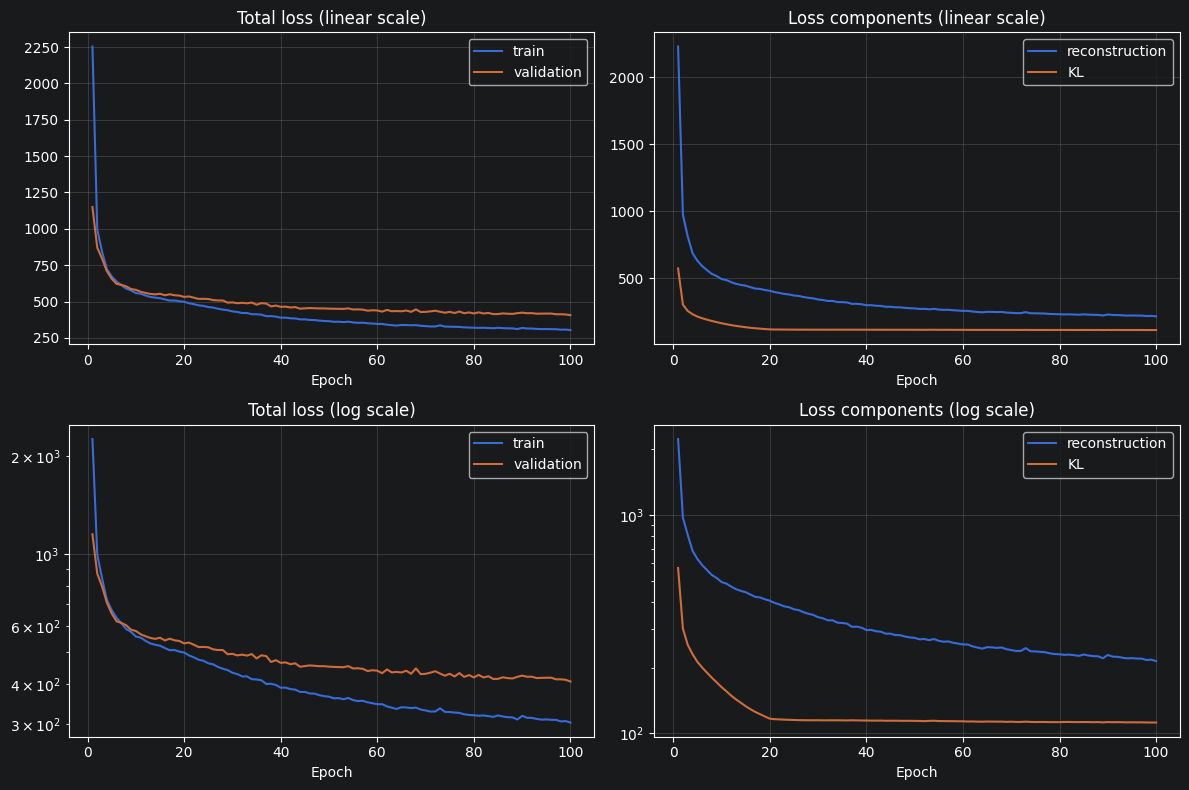

Generated → Inception: 79it [00:08,  8.93it/s]


FID: 48.839 (sampling took 00:00:20)


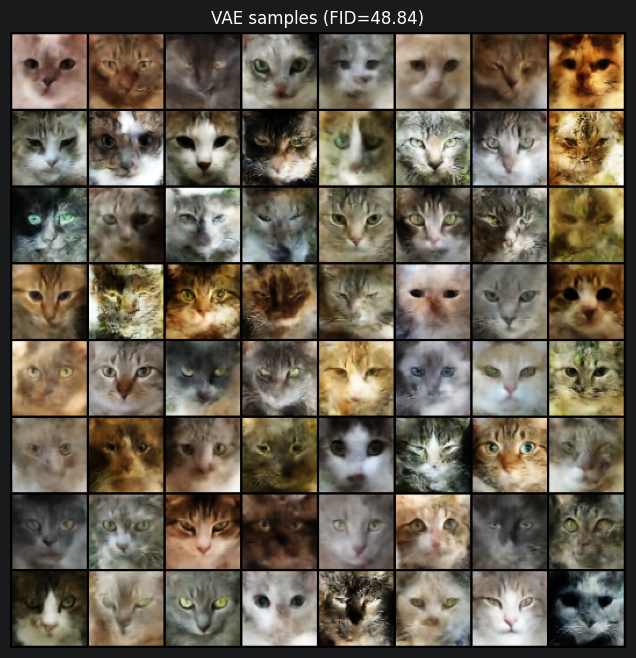

In [11]:
device = next(model.parameters()).device

with torch.no_grad():
    z = torch.randn(64, model.latent_dim, device=device)
    save_sample_grid(model.decode(z), paths["figures"] / "samples_final.png", nrow=8)

metrics_df = pd.DataFrame(history)
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, yscale in zip(axes[:, 0], ("linear", "log")):
    ax.plot(metrics_df["epoch"], metrics_df["loss"], label="train")
    ax.plot(metrics_df["epoch"], metrics_df["validation_loss"], label="validation")
    ax.set_yscale(yscale)
    ax.set_title(f"Total loss ({yscale} scale)")
    ax.set_xlabel("Epoch"); ax.legend(); ax.grid(alpha=0.3)
for ax, yscale in zip(axes[:, 1], ("linear", "log")):
    ax.plot(metrics_df["epoch"], metrics_df["reconstruction"], label="reconstruction")
    ax.plot(metrics_df["epoch"], metrics_df["kl"], label="KL")
    ax.set_yscale(yscale)
    ax.set_title(f"Loss components ({yscale} scale)")
    ax.set_xlabel("Epoch"); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

sampler = vae_sample_iterator(
    model,
    num_samples=experiment.train_fixed.fid_fake_samples,
    batch_size=run["train"]["batch_size"],
    device=device,
    seed=run["data"]["seed"],
)
fid_start = time.perf_counter()
fid_score = compute_fid(
    sampler,
    experiment.data_fixed,
    num_real_samples=experiment.train_fixed.fid_real_samples,
    seed=run["data"]["seed"],
    device=device,
)
fid_elapsed = time.perf_counter() - fid_start
report_fid(fid_score, elapsed_seconds=fid_elapsed)
save_json(paths["metrics"] / "fid.json", {"fid": fid_score, "elapsed_seconds": fid_elapsed})

img = plt.imread(paths["figures"] / "samples_final.png")
plt.figure(figsize=(8, 8))
plt.imshow(img); plt.axis("off")
plt.title(f"VAE samples (FID={fid_score:.2f})")
plt.show()


## Interpolation

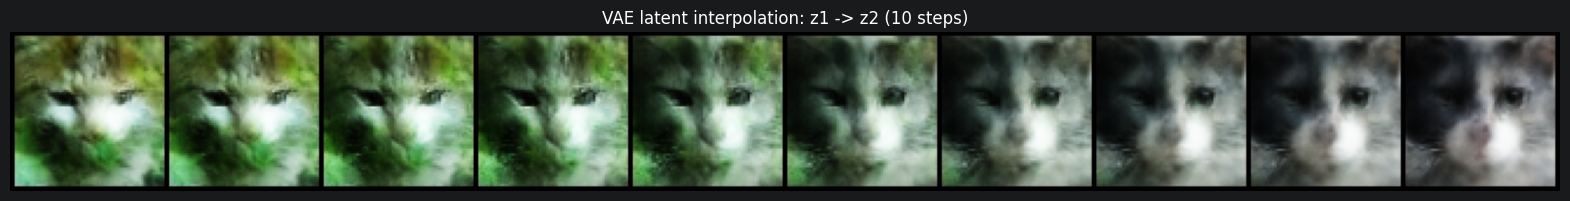

In [12]:
z1, z2 = sample_vae_latents(model, device, run["data"]["seed"])
images = interpolate_vae(model, z1, z2, num_steps=10)
interpolation_path = paths["figures"] / "interpolation.png"
save_interpolation_grid(images, interpolation_path)

img = plt.imread(interpolation_path)
plt.figure(figsize=(20, 2.6))
plt.imshow(img); plt.axis("off")
plt.title("VAE latent interpolation: z1 -> z2 (10 steps)")
plt.show()
